<a href="https://colab.research.google.com/github/Harzeezwed/Industrial-Defect-Classification-Small-Data/blob/main/Small_Sample_Learning_for_Defect_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

drive_path = '/content/drive/MyDrive/Dataset/Data/small_sample_20'
print(f"Files in '{drive_path}':")
for filename in os.listdir(drive_path):
    print(filename)

Mounted at /content/drive
Files in '/content/drive/MyDrive/Dataset/Data/small_sample_20':
defect10
defect1
good
defect5
defect8
defect3
defect2
defect9
defect4


In [ ]:
# ================================
# 1. Mount Google Drive
# ================================
from google.colab import drive
drive.mount('/content/drive')

# ================================
# 2. Check Dataset Path
# ================================


drive_path = '/content/drive/MyDrive/Dataset/Data/small_sample_20'

print("Checking dataset directory...\n")

if os.path.exists(drive_path):
    print("Dataset found!\n")
    print("Folders inside dataset:")
    print(os.listdir(drive_path))
else:
    print("Dataset path not found. Check your Google Drive path.")

# ================================
# 3. Import Libraries
# ================================

import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive


# ================================
# 4. Image Transformations
# ================================
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),   # convert grayscale to RGB
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking dataset directory...

Dataset found!

Folders inside dataset:
['defect10', 'defect1', 'good', 'defect5', 'defect8', 'defect3', 'defect2', 'defect9', 'defect4']


In [ ]:

# ================================
# 5. Load Dataset
# ================================
train_data = datasets.ImageFolder(
    root=drive_path,
    transform=data_transforms
)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

print("\nClasses detected:")
print(train_data.classes)

num_classes = len(train_data.classes)




Classes detected:
['defect1', 'defect10', 'defect2', 'defect3', 'defect4', 'defect5', 'defect8', 'defect9', 'good']


In [ ]:


# Define the base path where images are currently located
base_path = drive_path # This variable is already defined in the notebook

print(f"Restructuring dataset in: {base_path}")

# Get all files in the base path
all_files = [f for f in os.listdir(base_path) if os.path.isfile(os.path.join(base_path, f))]

# Extract unique class names from filenames (e.g., 'defect1', 'good')
class_names = set()
for filename in all_files:
    # Assuming class name is the part before the first underscore
    parts = filename.split('_')
    if len(parts) > 1:
        class_names.add(parts[0])

print(f"Identified classes: {list(class_names)}")

# Create subdirectories for each class if they don't exist
for class_name in class_names:
    class_dir = os.path.join(base_path, class_name)
    if not os.path.exists(class_dir):
        os.makedirs(class_dir)
        print(f"Created directory: {class_dir}")

# Move images into their respective class directories
for filename in all_files:
    parts = filename.split('_')
    if len(parts) > 1:
        class_name = parts[0]
        source_path = os.path.join(base_path, filename)
        destination_path = os.path.join(base_path, class_name, filename)
        try:
            shutil.move(source_path, destination_path)
            # print(f"Moved {filename} to {class_name}/")
        except Exception as e:
            print(f"Error moving {filename}: {e}")

print("Dataset restructuring complete!")

# Verify the new structure (optional)
print("\nNew directory structure:")
for class_name in class_names:
    class_dir = os.path.join(base_path, class_name)
    print(f"  {class_name}/: {len(os.listdir(class_dir))} files")

Restructuring dataset in: /content/drive/MyDrive/Dataset/Data/small_sample_20
Identified classes: []
Dataset restructuring complete!

New directory structure:


In [ ]:
# Re-running the Load Dataset section after restructuring

# ================================
# 5. Load Dataset
# ================================
train_data = datasets.ImageFolder(
    root=drive_path,
    transform=data_transforms
)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    drop_last=True # Added to avoid BatchNorm1d error with single-sample batches
)

print("\nClasses detected:")
print(train_data.classes)

num_classes = len(train_data.classes)

print(f"Number of classes: {num_classes}")


Classes detected:
['defect1', 'defect10', 'defect2', 'defect3', 'defect4', 'defect5', 'defect8', 'defect9', 'good']
Number of classes: 9


In [ ]:
# ================================
# 6. Device (GPU if available)
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# ================================
# 7. Load EfficientNet Model
# ================================
def get_model(num_classes):

    model = models.efficientnet_b0(weights='IMAGENET1K_V1')

    num_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Linear(512, num_classes)
    )

    return model

model = get_model(num_classes)
model = model.to(device)

# ================================
# 8. Loss Function + Optimizer
# ================================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ================================
# 9. Training Loop
# ================================
def train_model(model, loader, epochs=10):

    model.train()
    history = [] # To store epoch losses

    for epoch in range(epochs):

        running_loss = 0.0

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader)
        history.append(epoch_loss) # Store the loss

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")
    return history # Return the history

# ================================
# 10. Start Training
# ================================
training_history = train_model(model, train_loader, epochs=10)

print("\nTraining Complete!")



Using device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 173MB/s]


Epoch [1/10] Loss: 1.9533
Epoch [2/10] Loss: 1.0197
Epoch [3/10] Loss: 0.5131
Epoch [4/10] Loss: 0.3462
Epoch [5/10] Loss: 0.2531
Epoch [6/10] Loss: 0.1987
Epoch [7/10] Loss: 0.1402
Epoch [8/10] Loss: 0.1228
Epoch [9/10] Loss: 0.0754
Epoch [10/10] Loss: 0.1377

Training Complete!


In [ ]:

def evaluate_model(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 1. Classification Report (Precision, Recall, F1)
    print(classification_report(all_labels, all_preds, target_names=classes))

    # 2. Confusion Matrix Plot
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Defect Classification Confusion Matrix')
    plt.show()

# Usage (assuming 'val_loader' and 'class_names' exist)
# evaluate_model(model, val_loader, train_data.classes)


Evaluating model performance on training data...
              precision    recall  f1-score   support

     defect1       1.00      1.00      1.00        20
    defect10       1.00      1.00      1.00        20
     defect2       1.00      1.00      1.00        20
     defect3       1.00      1.00      1.00         9
     defect4       1.00      1.00      1.00        14
     defect5       1.00      1.00      1.00        20
     defect8       1.00      1.00      1.00        20
     defect9       1.00      1.00      1.00        20
        good       1.00      1.00      1.00        49

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192



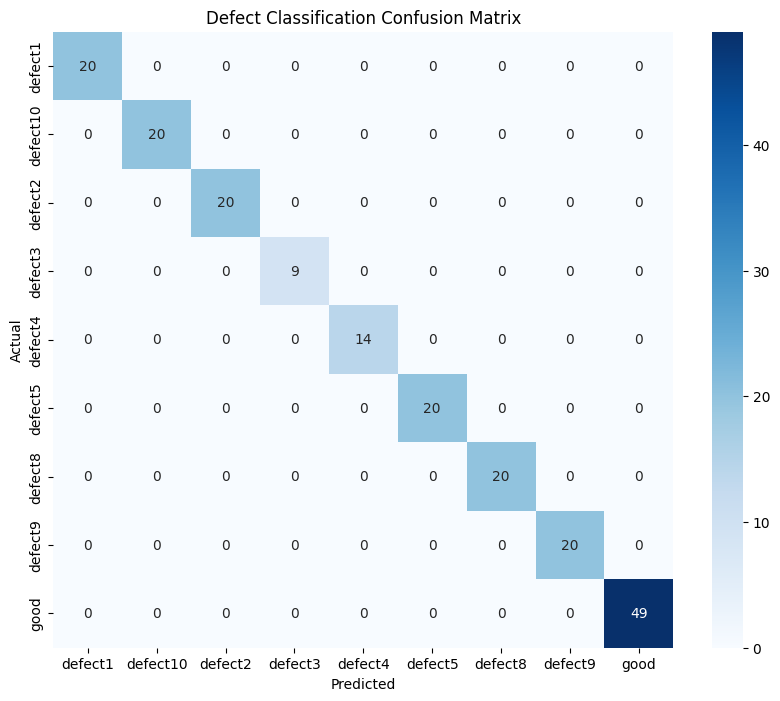

In [ ]:
print("\nEvaluating model performance on training data...")
# Call the evaluation function with the trained model, train_loader, and detected classes
evaluate_model(model, train_loader, train_data.classes)

In [ ]:


def evaluate_model(model, loader, classes):
    model.eval()  # Set to evaluation mode (turns off Dropout/BatchNorm)
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Print overall accuracy
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nOverall Training Accuracy: {accuracy*100:.2f}%")

    # Detailed report per defect class
    print("\nDetailed Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))


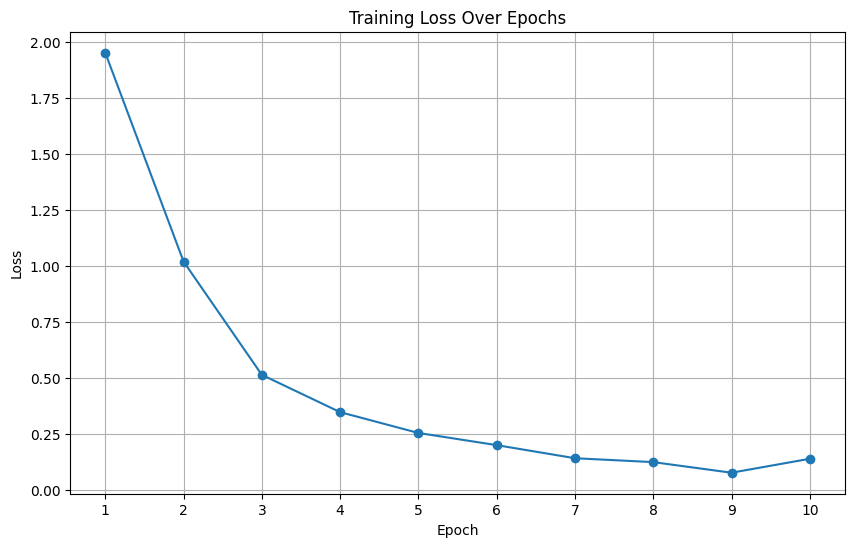

In [ ]:


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(training_history) + 1), training_history, marker='o')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, len(training_history) + 1))
plt.show()

Starting the complete workflow...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Checking dataset directory...
Dataset found!
Folders inside dataset:
['defect10', 'defect1', 'good', 'defect5', 'defect8', 'defect3', 'defect2', 'defect9', 'defect4']

Classes detected:
['defect1', 'defect10', 'defect2', 'defect3', 'defect4', 'defect5', 'defect8', 'defect9', 'good']
Number of classes: 9
Total dataset size: 193
Training dataset size: 154
Test dataset size: 39
Train DataLoader created with 4 batches.
Test DataLoader created with 2 batches.

Using device: cpu

Starting training...
Epoch [1/10] Loss: 1.9637
Epoch [2/10] Loss: 0.9528
Epoch [3/10] Loss: 0.6968
Epoch [4/10] Loss: 0.3717
Epoch [5/10] Loss: 0.3084
Epoch [6/10] Loss: 0.1877
Epoch [7/10] Loss: 0.1410
Epoch [8/10] Loss: 0.1432
Epoch [9/10] Loss: 0.1754
Epoch [10/10] Loss: 0.1860

Training Complete!


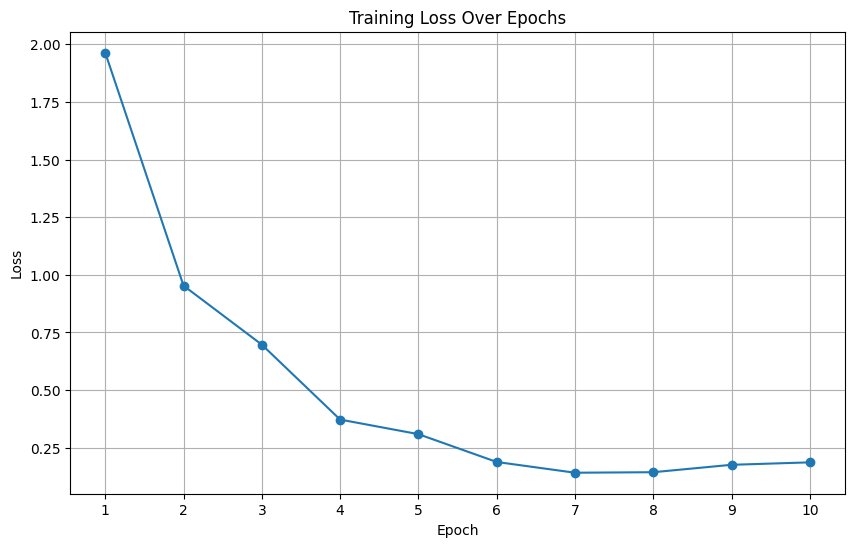


Evaluating model performance on training data...

Overall Accuracy: 99.22%

Detailed Classification Report:
              precision    recall  f1-score   support

     defect1       1.00      1.00      1.00        13
    defect10       1.00      1.00      1.00        14
     defect2       1.00      1.00      1.00        11
     defect3       1.00      1.00      1.00         4
     defect4       1.00      1.00      1.00        10
     defect5       1.00      0.92      0.96        12
     defect8       1.00      1.00      1.00        14
     defect9       1.00      1.00      1.00        16
        good       0.97      1.00      0.99        34

    accuracy                           0.99       128
   macro avg       1.00      0.99      0.99       128
weighted avg       0.99      0.99      0.99       128



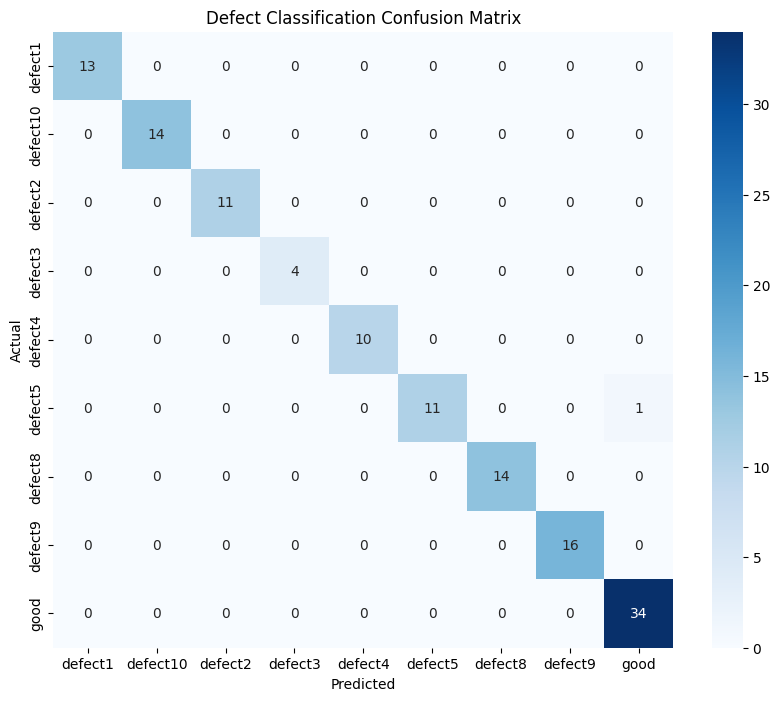


Evaluating model performance on test data...

Overall Accuracy: 48.72%

Detailed Classification Report:
              precision    recall  f1-score   support

     defect1       0.80      0.80      0.80         5
    defect10       1.00      0.20      0.33         5
     defect2       0.67      0.67      0.67         3
     defect3       1.00      0.75      0.86         4
     defect4       1.00      1.00      1.00         3
     defect5       0.25      0.33      0.29         3
     defect8       0.00      0.00      0.00         4
     defect9       0.33      0.50      0.40         2
        good       0.27      0.40      0.32        10

    accuracy                           0.49        39
   macro avg       0.59      0.52      0.52        39
weighted avg       0.57      0.49      0.49        39



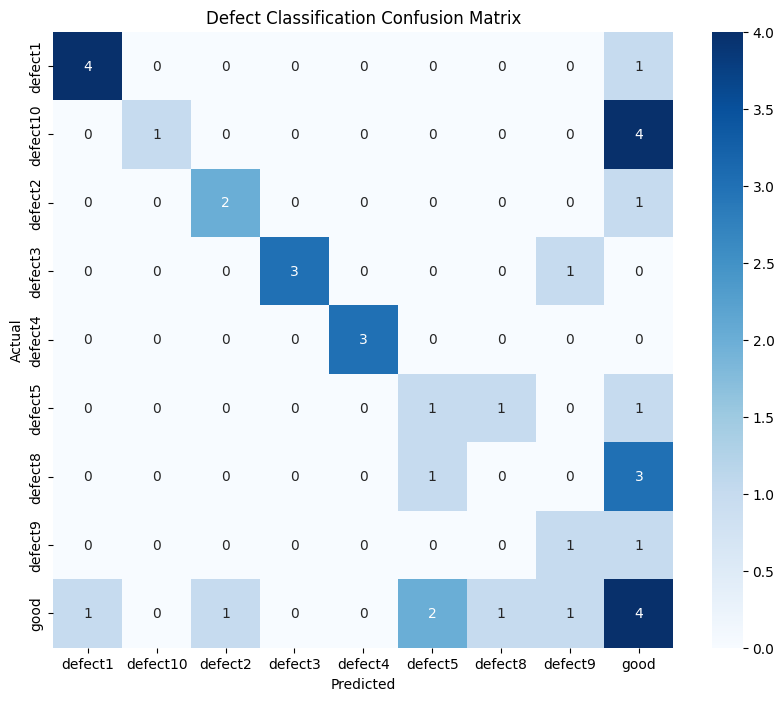


Workflow Complete!


In [ ]:


print("Starting the complete workflow...")

# ================================1. Mount Google Drive ================================
drive.mount('/content/drive')

# ================================2. Check Dataset Path ================================
drive_path = '/content/drive/MyDrive/Dataset/Data/small_sample_20'
print("\nChecking dataset directory...")

if os.path.exists(drive_path):
    print("Dataset found!")
    print("Folders inside dataset:")
    print(os.listdir(drive_path))
else:
    print("Dataset path not found. Check your Google Drive path.")
    # Exit or raise error if dataset not found

# ================================3. Image Transformations ================================
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),   # convert grayscale to RGB
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ================================4. Load Dataset and Split ================================
total_dataset = datasets.ImageFolder(
    root=drive_path,
    transform=data_transforms
)

print("\nClasses detected:")
print(total_dataset.classes)
num_classes = len(total_dataset.classes)
print(f"Number of classes: {num_classes}")

# Calculate the size of the training and test sets (80/20 split)
total_size = len(total_dataset)
train_size = int(0.8 * total_size)
test_size = total_size - train_size

# Split the dataset
train_dataset, test_dataset = random_split(total_dataset, [train_size, test_size])

print(f"Total dataset size: {total_size}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)
print(f"Train DataLoader created with {len(train_loader)} batches.")
print(f"Test DataLoader created with {len(test_loader)} batches.")

# ================================5. Device (GPU if available) ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# ================================6. Load EfficientNet Model ================================
def get_model(num_classes):
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Linear(512, num_classes)
    )
    return model

model = get_model(num_classes)
model = model.to(device)

# ================================7. Loss Function + Optimizer ================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ================================8. Training Loop ================================
def train_model(model, loader, epochs=10):
    model.train()
    history = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss / len(loader)
        history.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")
    return history

print("\nStarting training...")
training_history = train_model(model, train_loader, epochs=10)
print("\nTraining Complete!")

# ================================9. Plot Training Loss ================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(training_history) + 1), training_history, marker='o')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, len(training_history) + 1))
plt.show()

# ================================10. Evaluation Function ================================
def evaluate_model(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Overall Accuracy
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nOverall Accuracy: {accuracy*100:.2f}%")

    # Classification Report (Precision, Recall, F1)
    print("\nDetailed Classification Report:")
    print(classification_report(all_labels, all_preds, labels=range(len(classes)), target_names=classes))

    # Confusion Matrix Plot
    cm = confusion_matrix(all_labels, all_preds, labels=range(len(classes)))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Defect Classification Confusion Matrix')
    plt.show()

# ================================11. Evaluate Model ================================
print("\nEvaluating model performance on training data...")
evaluate_model(model, train_loader, total_dataset.classes)

print("\nEvaluating model performance on test data...")
evaluate_model(model, test_loader, total_dataset.classes)

print("\nWorkflow Complete!")

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split
from google.colab import drive
import os

# Mount Google Drive to ensure access
drive.mount('/content/drive')

# Define drive_path (from earlier in the notebook)
drive_path = '/content/drive/MyDrive/Dataset/Data/small_sample_20'

# Optional: Verify path existence and contents
print(f"Checking drive path: {drive_path}")
if os.path.exists(drive_path):
    print("Path exists.")
    # Only print contents if it's a directory to avoid error on non-dir files
    if os.path.isdir(drive_path):
        print(f"Contents: {os.listdir(drive_path)}")
    else:
        print("Path is not a directory.")
else:
    print("Path does NOT exist. Please verify your Google Drive setup and path.")

# Define data_transforms (from earlier in the notebook)
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),   # convert grayscale to RGB
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# Define train_data (from earlier in the notebook)
train_data = datasets.ImageFolder(
    root=drive_path,
    transform=data_transforms
)

# Calculate the size of the training and test sets (80/20 split)
total_size = len(train_data)
train_size = int(0.8 * total_size)
test_size = total_size - train_size

# Split the dataset
train_dataset, test_dataset = random_split(train_data, [train_size, test_size])

print(f"Total dataset size: {total_size}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

In [ ]:
from torch.utils.data import DataLoader

# Create DataLoader for the test set
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(f"Test DataLoader created with {len(test_loader)} batches.")

In [ ]:
from torch.utils.data import DataLoader

# Create DataLoader for the test set
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(f"Test DataLoader created with {len(test_loader)} batches.")

Test DataLoader created with 2 batches.


Starting the complete workflow...
Mounted at /content/drive

Checking dataset directory...
Dataset found!
Folders inside dataset:
['defect9', 'defect8', 'defect4', 'good', 'defect5', 'defect2', 'defect3', 'defect1', 'defect10']

Classes detected:
['defect1', 'defect10', 'defect2', 'defect3', 'defect4', 'defect5', 'defect8', 'defect9', 'good']
Number of classes: 9
Total dataset size: 9047
Training dataset size: 7237
Test dataset size: 1810
Train DataLoader created with 226 batches.
Test DataLoader created with 57 batches.

Using device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 88.9MB/s]



Starting training...
Epoch [1/20] Loss: 1.3335
Epoch [2/20] Loss: 0.7442
Epoch [3/20] Loss: 0.6538
Epoch [4/20] Loss: 0.5885
Epoch [5/20] Loss: 0.5530
Epoch [6/20] Loss: 0.5098
Epoch [7/20] Loss: 0.4736
Epoch [8/20] Loss: 0.4689
Epoch [9/20] Loss: 0.4287
Epoch [10/20] Loss: 0.4123
Epoch [11/20] Loss: 0.4019
Epoch [12/20] Loss: 0.3993
Epoch [13/20] Loss: 0.3698
Epoch [14/20] Loss: 0.3513
Epoch [15/20] Loss: 0.3326
Epoch [16/20] Loss: 0.3244
Epoch [17/20] Loss: 0.2962
Epoch [18/20] Loss: 0.2833
Epoch [19/20] Loss: 0.3139
Epoch [20/20] Loss: 0.3134

Training Complete!


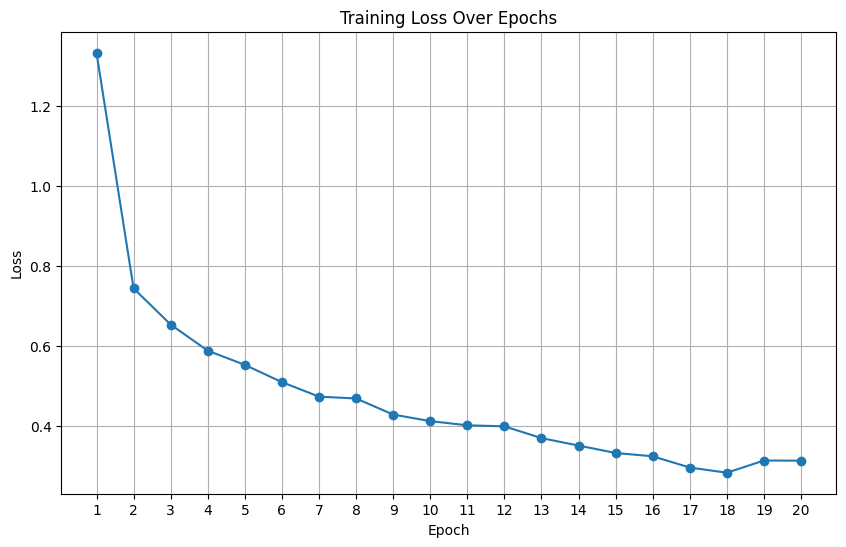


Evaluating model performance on training data...

Overall Accuracy: 88.12%

Detailed Classification Report:
              precision    recall  f1-score   support

     defect1       0.52      0.96      0.68       676
    defect10       0.00      0.00      0.00       538
     defect2       0.94      0.94      0.94        69
     defect3       1.00      0.38      0.55         8
     defect4       1.00      0.77      0.87        13
     defect5       0.86      0.96      0.91       259
     defect8       0.95      0.85      0.90       577
     defect9       0.94      0.76      0.84       178
        good       0.96      0.97      0.97      4914

    accuracy                           0.88      7232
   macro avg       0.80      0.73      0.74      7232
weighted avg       0.84      0.88      0.86      7232



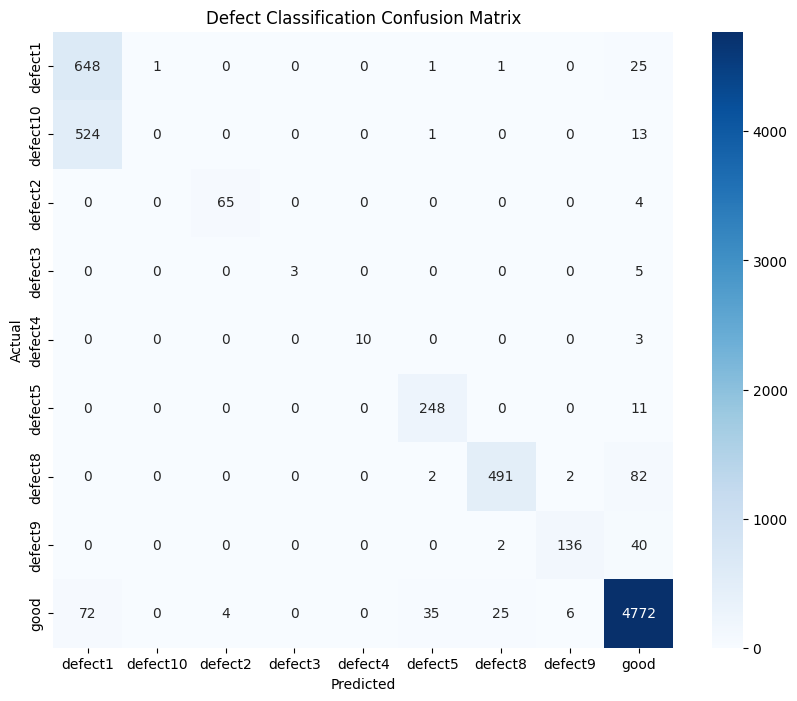


Evaluating model performance on test data...

Overall Accuracy: 80.33%

Detailed Classification Report:
              precision    recall  f1-score   support

     defect1       0.45      0.86      0.59       161
    defect10       0.00      0.00      0.00       136
     defect2       0.79      0.55      0.65        20
     defect3       0.00      0.00      0.00         1
     defect4       1.00      0.50      0.67         2
     defect5       0.77      0.78      0.77        63
     defect8       0.77      0.57      0.65       136
     defect9       0.79      0.44      0.57        52
        good       0.89      0.93      0.91      1239

    accuracy                           0.80      1810
   macro avg       0.61      0.51      0.53      1810
weighted avg       0.77      0.80      0.78      1810



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


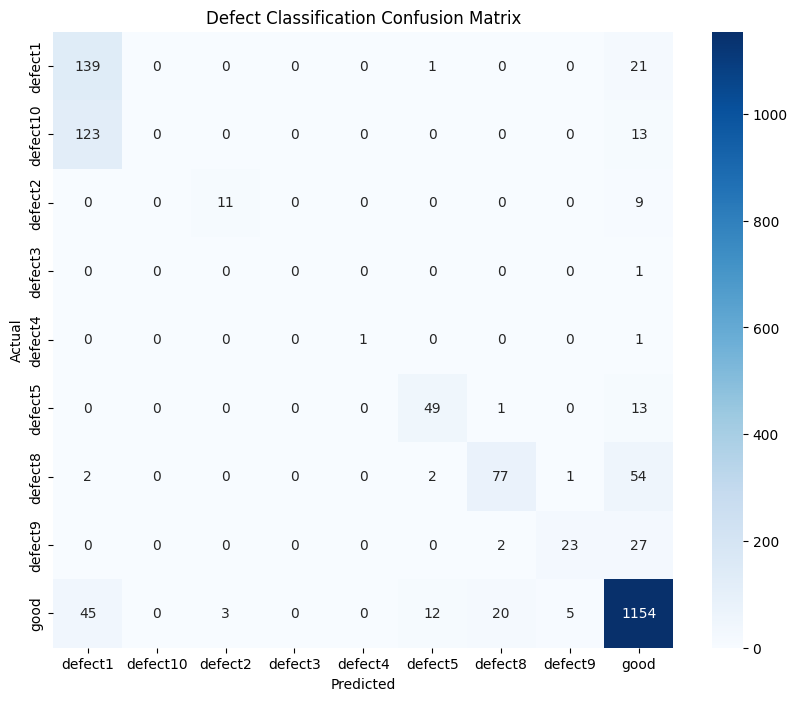


Workflow Complete!
CPU times: user 9h 51min 43s, sys: 1h 7min 55s, total: 10h 59min 39s
Wall time: 11h 53min 52s


In [ ]:
%%time

import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive

print("Starting the complete workflow...")

# ================================1. Mount Google Drive ================================
drive.mount('/content/drive')

# ================================2. Check Dataset Path ================================
drive_path = '/content/drive/MyDrive/Dataset/Data/small_sample'
print("\nChecking dataset directory...")

if os.path.exists(drive_path):
    print("Dataset found!")
    print("Folders inside dataset:")
    print(os.listdir(drive_path))
else:
    print("Dataset path not found. Check your Google Drive path.")
    # Exit or raise error if dataset not found

# ================================3. Image Transformations ================================
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),   # convert grayscale to RGB
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ================================4. Load Dataset and Split ================================
total_dataset = datasets.ImageFolder(
    root=drive_path,
    transform=data_transforms
)

print("\nClasses detected:")
print(total_dataset.classes)
num_classes = len(total_dataset.classes)
print(f"Number of classes: {num_classes}")

# Calculate the size of the training and test sets (80/20 split)
total_size = len(total_dataset)
train_size = int(0.8 * total_size)
test_size = total_size - train_size

# Split the dataset
train_dataset, test_dataset = random_split(total_dataset, [train_size, test_size])

print(f"Total dataset size: {total_size}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)
print(f"Train DataLoader created with {len(train_loader)} batches.")
print(f"Test DataLoader created with {len(test_loader)} batches.")

# ================================5. Device (GPU if available) ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# ================================6. Load EfficientNet Model ================================
def get_model(num_classes):
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Linear(512, num_classes)
    )
    return model

model = get_model(num_classes)
model = model.to(device)

# ================================7. Loss Function + Optimizer ================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ================================8. Training Loop ================================
def train_model(model, loader, epochs=20):
    model.train()
    history = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss / len(loader)
        history.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")
    return history

print("\nStarting training...")
training_history = train_model(model, train_loader, epochs=20)
print("\nTraining Complete!")

# ================================9. Plot Training Loss ================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(training_history) + 1), training_history, marker='o')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, len(training_history) + 1))
plt.show()

# ================================10. Evaluation Function ================================
def evaluate_model(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Overall Accuracy
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nOverall Accuracy: {accuracy*100:.2f}%")

    # Classification Report (Precision, Recall, F1)
    print("\nDetailed Classification Report:")
    print(classification_report(all_labels, all_preds, labels=range(len(classes)), target_names=classes))

    # Confusion Matrix Plot
    cm = confusion_matrix(all_labels, all_preds, labels=range(len(classes)))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Defect Classification Confusion Matrix')
    plt.show()

# ================================11. Evaluate Model ================================
print("\nEvaluating model performance on training data...")
evaluate_model(model, train_loader, total_dataset.classes)

print("\nEvaluating model performance on test data...")
evaluate_model(model, test_loader, total_dataset.classes)

print("\nWorkflow Complete!")